In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE


In [2]:
df = pd.read_csv("dataset/final_ml_dataset.csv", low_memory=False)

In [3]:
df.head(n=10)

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,flow_id,tls.handshake.ja3,tls.handshake.extensions_server_name
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443.0,192.168.10.5,54865.0,6.0,7/7/2017 3:30,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,104.16.207.165:443-192.168.10.5:54865,0ffee3ba8e615ad22535e7f771690a28,cdn.onesignal.com
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80.0,192.168.10.5,55054.0,6.0,7/7/2017 3:30,109.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,104.16.28.216:80-192.168.10.5:55054,NaN,NaN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80.0,192.168.10.5,55055.0,6.0,7/7/2017 3:30,52.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,104.16.28.216:80-192.168.10.5:55055,NaN,NaN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443.0,192.168.10.16,46236.0,6.0,7/7/2017 3:30,34.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,104.17.241.25:443-192.168.10.16:46236,0ffee3ba8e615ad22535e7f771690a28,www.hollywoodreporter.com
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443.0,192.168.10.5,54863.0,6.0,7/7/2017 3:30,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,104.19.196.102:443-192.168.10.5:54863,0ffee3ba8e615ad22535e7f771690a28,cdnjs.cloudflare.com
5,192.168.10.5-104.20.10.120-54871-443-6,104.20.10.120,443.0,192.168.10.5,54871.0,6.0,7/7/2017 3:30,1022.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,104.20.10.120:443-192.168.10.5:54871,0ffee3ba8e615ad22535e7f771690a28,i.dawn.com
6,192.168.10.5-104.20.10.120-54925-443-6,104.20.10.120,443.0,192.168.10.5,54925.0,6.0,7/7/2017 3:30,4.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,104.20.10.120:443-192.168.10.5:54925,1a5fe5677b0e4fbbc854e8908225637d,www.dawn.com
7,192.168.10.5-104.20.10.120-54925-443-6,104.20.10.120,443.0,192.168.10.5,54925.0,6.0,7/7/2017 3:30,42.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,104.20.10.120:443-192.168.10.5:54925,1a5fe5677b0e4fbbc854e8908225637d,www.dawn.com
8,192.168.10.8-104.28.13.116-9282-443-6,104.28.13.116,443.0,192.168.10.8,9282.0,6.0,7/7/2017 3:30,4.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,104.28.13.116:443-192.168.10.8:9282,61d0d709fe7ac199ef4b2c52bc8cef75,www.la-roza.com
9,192.168.10.5-104.97.123.193-55153-443-6,104.97.123.193,443.0,192.168.10.5,55153.0,6.0,7/7/2017 3:30,4.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,104.97.123.193:443-192.168.10.5:55153,0ffee3ba8e615ad22535e7f771690a28,ad.yieldlab.net


In [4]:
df.describe()

C:\Users\marco\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\marco\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,4.112886e+04,8.071483e+03,9.880341e+00,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,2.229494e+04,1.828363e+04,5.261922e+00,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.277400e+04,5.300000e+01,6.000000e+00,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.094400e+04,8.000000e+01,6.000000e+00,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,5.841300e+04,4.430000e+02,1.700000e+01,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,6.553500e+04,1.700000e+01,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [5]:
df["Label"].value_counts()

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack  Brute Force         1507
Web Attack  XSS                  652
Infiltration                       36
Web Attack  Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [6]:
df.dtypes

Flow ID                                  object
Source IP                                object
Source Port                             float64
Destination IP                           object
Destination Port                        float64
                                         ...   
Idle Min                                float64
Label                                    object
flow_id                                  object
tls.handshake.ja3                        object
tls.handshake.extensions_server_name     object
Length: 88, dtype: object

In [7]:
list(df.columns)

['Flow ID',
 'Source IP',
 'Source Port',
 'Destination IP',
 'Destination Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag 

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3119345 entries, 0 to 3119344
Data columns (total 88 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   Flow ID                               object 
 1   Source IP                             object 
 2   Source Port                           float64
 3   Destination IP                        object 
 4   Destination Port                      float64
 5   Protocol                              float64
 6   Timestamp                             object 
 7   Flow Duration                         float64
 8   Total Fwd Packets                     float64
 9   Total Backward Packets                float64
 10  Total Length of Fwd Packets           float64
 11  Total Length of Bwd Packets           float64
 12  Fwd Packet Length Max                 float64
 13  Fwd Packet Length Min                 float64
 14  Fwd Packet Length Mean                float64
 15  Fwd Packet Leng

In [ ]:
df["tls.handshake.ja3"] = df["tls.handshake.ja3"].fillna("NO_TLS")
df["tls.handshake.extensions_server_name"] = (
    df["tls.handshake.extensions_server_name"].fillna("NO_SNI")
)

le_ja3 = LabelEncoder()
df["ja3_enc"] = le_ja3.fit_transform(df["tls.handshake.ja3"])

le_sni = LabelEncoder()
df["sni_enc"] = le_sni.fit_transform(df["tls.handshake.extensions_server_name"])

df["has_tls"] = (df["tls.handshake.ja3"] != "NO_TLS").astype(int)


In [ ]:
drop_cols = [
    "Flow ID",
    "flow_id",
    "Timestamp",
    "Source IP",
    "Destination IP",
    "tls.handshake.ja3",
    "tls.handshake.extensions_server_name",
]

drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)

y = df["Label"]
X = df.drop(columns=["Label"])


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3119345 entries, 0 to 3119344
Data columns (total 84 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Source Port                  float64
 1   Destination Port             float64
 2   Protocol                     float64
 3   Flow Duration                float64
 4   Total Fwd Packets            float64
 5   Total Backward Packets       float64
 6   Total Length of Fwd Packets  float64
 7   Total Length of Bwd Packets  float64
 8   Fwd Packet Length Max        float64
 9   Fwd Packet Length Min        float64
 10  Fwd Packet Length Mean       float64
 11  Fwd Packet Length Std        float64
 12  Bwd Packet Length Max        float64
 13  Bwd Packet Length Min        float64
 14  Bwd Packet Length Mean       float64
 15  Bwd Packet Length Std        float64
 16  Flow Bytes/s                 float64
 17  Flow Packets/s               float64
 18  Flow IAT Mean                float64
 19  

In [ ]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

y = y.fillna("UNKNOWN")


In [13]:
print("NaN X:", X.isna().sum().sum())
print("NaN y:", y.isna().sum())

NaN X: 0
NaN y: 0


In [14]:
le = LabelEncoder()
df["Label"] = le.fit_transform(df["Label"])


In [15]:
df.corr(numeric_only=True)


,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,ja3_enc,sni_enc,has_tls
Source Port,1.000000,-0.694152,0.295143,0.087144,0.002841,0.002955,-0.008677,0.002455,-0.071637,0.046308,...,0.008086,0.007267,0.073993,0.014528,0.073941,0.072550,0.113758,0.142370,-0.234678,-0.292943
Destination Port,-0.694152,1.000000,-0.320458,-0.151680,-0.004236,-0.003947,0.011145,-0.003082,0.097926,-0.045388,...,-0.051859,-0.023194,-0.112585,0.010399,-0.108185,-0.114614,-0.078526,-0.071530,0.254022,0.316497
Protocol,0.295143,-0.320458,1.000000,-0.265275,-0.007272,-0.006361,-0.033234,-0.005191,-0.166066,0.315250,...,-0.109356,-0.063663,-0.179676,-0.071305,-0.184514,-0.170531,-0.304670,0.196853,-0.369706,-0.455406
Flow Duration,0.087144,-0.151680,-0.265275,1.000000,0.020857,0.019670,0.065456,0.016186,0.273308,-0.105230,...,0.294034,0.121171,0.768034,0.243154,0.779527,0.738328,0.072592,-0.061958,0.061468,0.067063
Total Fwd Packets,0.002841,-0.004236,-0.007272,0.020857,1.000000,0.999070,0.365508,0.996993,0.009358,-0.002989,...,0.030459,0.041283,0.001820,0.000809,0.001906,0.001670,-0.003324,-0.001698,0.002342,0.002042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Idle Min,0.072550,-0.114614,-0.170531,0.738328,0.001670,0.001330,0.018634,0.000789,0.156973,-0.067435,...,0.077261,0.112880,0.990215,0.011609,0.961812,1.000000,0.187095,0.007313,-0.059049,-0.081756
Label,0.113758,-0.078526,-0.304670,0.072592,-0.003324,-0.003122,-0.014874,-0.002336,-0.068959,-0.115131,...,-0.027471,-0.002257,0.187675,0.023257,0.186252,0.187095,1.000000,0.126249,-0.235171,-0.287984
ja3_enc,0.142370,-0.071530,0.196853,-0.061958,-0.001698,-0.001430,-0.015119,-0.000367,-0.036430,0.070280,...,-0.061797,-0.036020,0.006462,-0.001698,0.005954,0.007313,0.126249,1.000000,-0.364781,-0.438381
sni_enc,-0.234678,0.254022,-0.369706,0.061468,0.002342,0.002040,0.026161,0.000309,0.075565,-0.137032,...,0.071373,0.038062,-0.059272,-0.016511,-0.060067,-0.059049,-0.235171,-0.364781,1.000000,0.816573


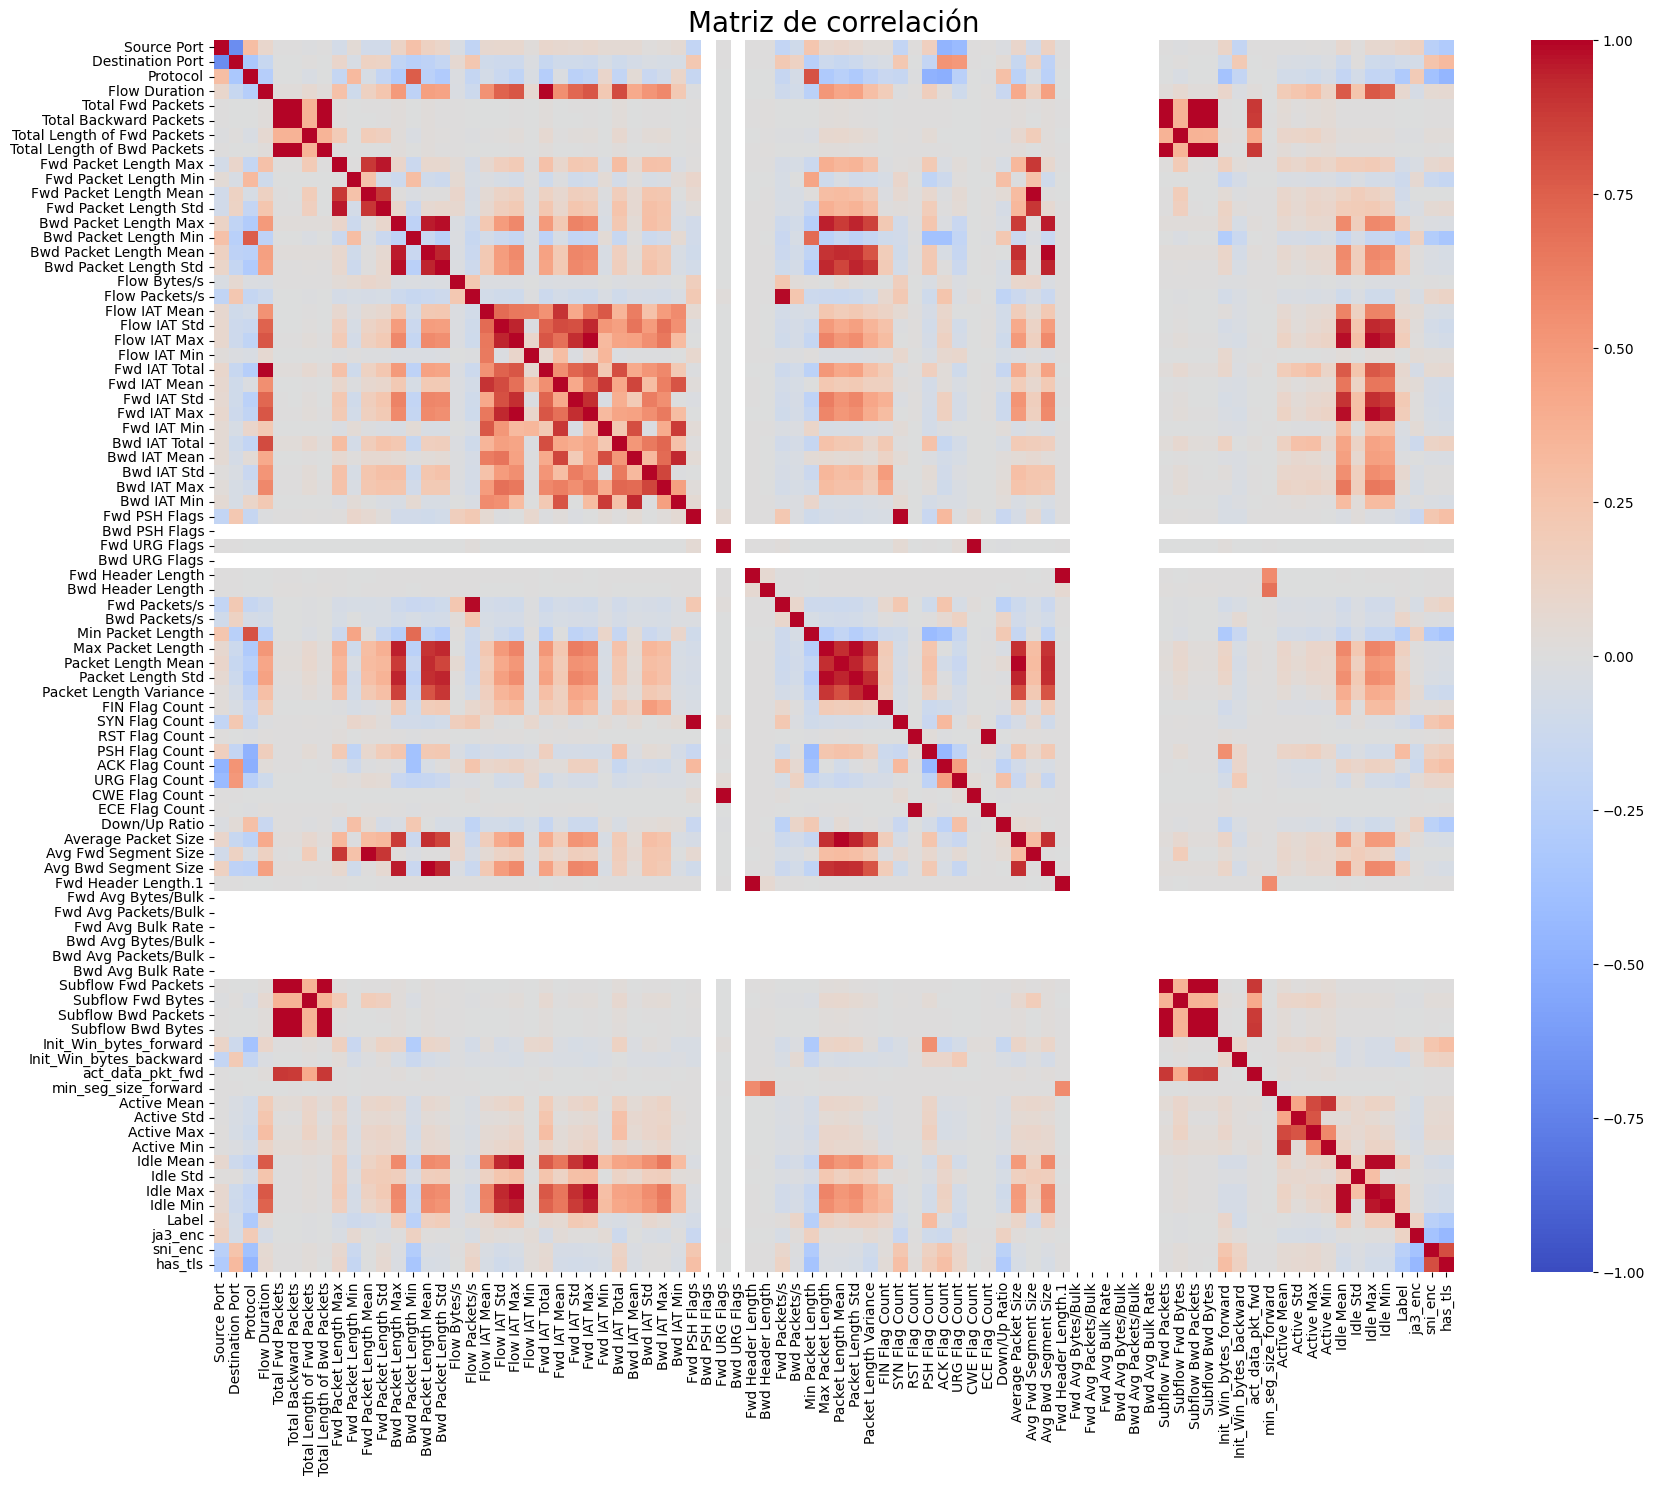

In [16]:
plt.figure(figsize=(20, 16))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Matriz de correlación', fontsize=20)
plt.show()


In [17]:
corr = df.corr(numeric_only=True)
corr_label = corr["Label"].drop("Label")
pos_corr = corr_label[corr_label > 0].sort_values(ascending=False)

print(pos_corr)

PSH Flag Count            0.305413
Fwd IAT Std               0.205842
Idle Mean                 0.187675
Idle Min                  0.187095
Idle Max                  0.186252
Fwd IAT Max               0.182371
Bwd Packet Length Std     0.182160
Flow IAT Max              0.181158
Bwd Packet Length Max     0.171966
Bwd Packet Length Mean    0.158172
Avg Bwd Segment Size      0.158172
Packet Length Variance    0.155879
Flow IAT Std              0.152930
Packet Length Std         0.151829
Max Packet Length         0.149638
ja3_enc                   0.126249
Source Port               0.113758
Packet Length Mean        0.111318
Bwd Packets/s             0.108456
Average Packet Size       0.107143
Init_Win_bytes_forward    0.101153
FIN Flag Count            0.095890
Bwd IAT Std               0.075865
Fwd IAT Total             0.074685
Flow Duration             0.072592
Flow IAT Mean             0.065027
Fwd IAT Mean              0.058529
Bwd IAT Max               0.043891
Flow Packets/s      

In [18]:
constant_cols = []
for col in df.select_dtypes(include=["number"]).columns:
    if df[col].nunique() <= 1:
        constant_cols.append(col)

print("Constantes:", constant_cols)
df.drop(columns=constant_cols, inplace=True)

Constantes: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3119345 entries, 0 to 3119344
Data columns (total 76 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Source Port                  float64
 1   Destination Port             float64
 2   Protocol                     float64
 3   Flow Duration                float64
 4   Total Fwd Packets            float64
 5   Total Backward Packets       float64
 6   Total Length of Fwd Packets  float64
 7   Total Length of Bwd Packets  float64
 8   Fwd Packet Length Max        float64
 9   Fwd Packet Length Min        float64
 10  Fwd Packet Length Mean       float64
 11  Fwd Packet Length Std        float64
 12  Bwd Packet Length Max        float64
 13  Bwd Packet Length Min        float64
 14  Bwd Packet Length Mean       float64
 15  Bwd Packet Length Std        float64
 16  Flow Bytes/s                 float64
 17  Flow Packets/s               float64
 18  Flow IAT Mean                float64
 19  

In [20]:
df["Label"] = le.inverse_transform(df["Label"])

In [21]:
df = df.dropna(subset=["Label"])

In [22]:
X = df.drop(columns=["Label"])
y = df["Label"]


In [23]:
X.columns

Index(['Source Port', 'Destination Port', 'Protocol', 'Flow Duration',
       'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count',
       '

In [24]:
y.value_counts()


Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack  Brute Force         1507
Web Attack  XSS                  652
Infiltration                       36
Web Attack  Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [ ]:
X = df.drop(columns=["Label"])
y = df["Label"]

mask = y.notna()
X = X[mask]
y = y[mask]
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [26]:
for v in pd.Series(y_train).unique():
    print(repr(v), type(v))

'DoS Hulk' <class 'str'>
'BENIGN' <class 'str'>
'Bot' <class 'str'>
'DDoS' <class 'str'>
'PortScan' <class 'str'>
'FTP-Patator' <class 'str'>
'SSH-Patator' <class 'str'>
'DoS GoldenEye' <class 'str'>
'DoS Slowhttptest' <class 'str'>
'Web Attack \x96 Brute Force' <class 'str'>
'DoS slowloris' <class 'str'>
'Web Attack \x96 XSS' <class 'str'>
'Infiltration' <class 'str'>
'Web Attack \x96 Sql Injection' <class 'str'>
'Heartbleed' <class 'str'>


In [ ]:
def simplify_label(label):
    label = str(label)
    if label == "BENIGN":
        return "BENIGN"
    if label.startswith("DDoS"):
        return "DDOS"
    elif label.startswith("DoS"):
        return "DOS"
    if "Web Attack" in label:
        return "WEB_ATTACK"
    if "PortScan" in label:
        return "PORTSCAN"
    if "FTP-Patator" in label or "SSH-Patator" in label:
        return "BRUTE_FORCE"
    if label == "Bot":
        return "BOT"
    if label == "Heartbleed":
        return "EXPLOIT"
    if label == "Infiltration":
        return "INFILTRATION"
    return "OTHER"

df["Label"] = df["Label"].apply(simplify_label)


In [28]:
df["Label"].value_counts()

Label
BENIGN          2273097
DOS              252661
PORTSCAN         158930
DDOS             128027
BRUTE_FORCE       13835
WEB_ATTACK         2180
BOT                1966
INFILTRATION         36
EXPLOIT              11
Name: count, dtype: int64

In [29]:
target_per_class = 7000

df_small = (
    df.groupby("Label", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), target_per_class),
        random_state=42
    ))
)

print(df_small["Label"].value_counts())


Label
BENIGN          7000
BRUTE_FORCE     7000
DDOS            7000
DOS             7000
PORTSCAN        7000
WEB_ATTACK      2180
BOT             1966
INFILTRATION      36
EXPLOIT           11
Name: count, dtype: int64


C:\Users\marco\AppData\Local\Temp\ipykernel_20468\2098541381.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [30]:
from sklearn.model_selection import train_test_split

X = df_small.drop(columns=["Label","has_tls","ja3_enc","sni_enc"])
y = df_small["Label"]

# quitar NaN en label
mask = y.notna()
X = X[mask]
y = y[mask]
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Importancia de variables

In [31]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

mi = mutual_info_classif(X_train, y_train)

scores = pd.Series(mi, index=X_train.columns)
scores = scores.sort_values(ascending=False)
scores_sorted = scores.sort_values(ascending=False)
selected_features = scores[scores > 0.05].index

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

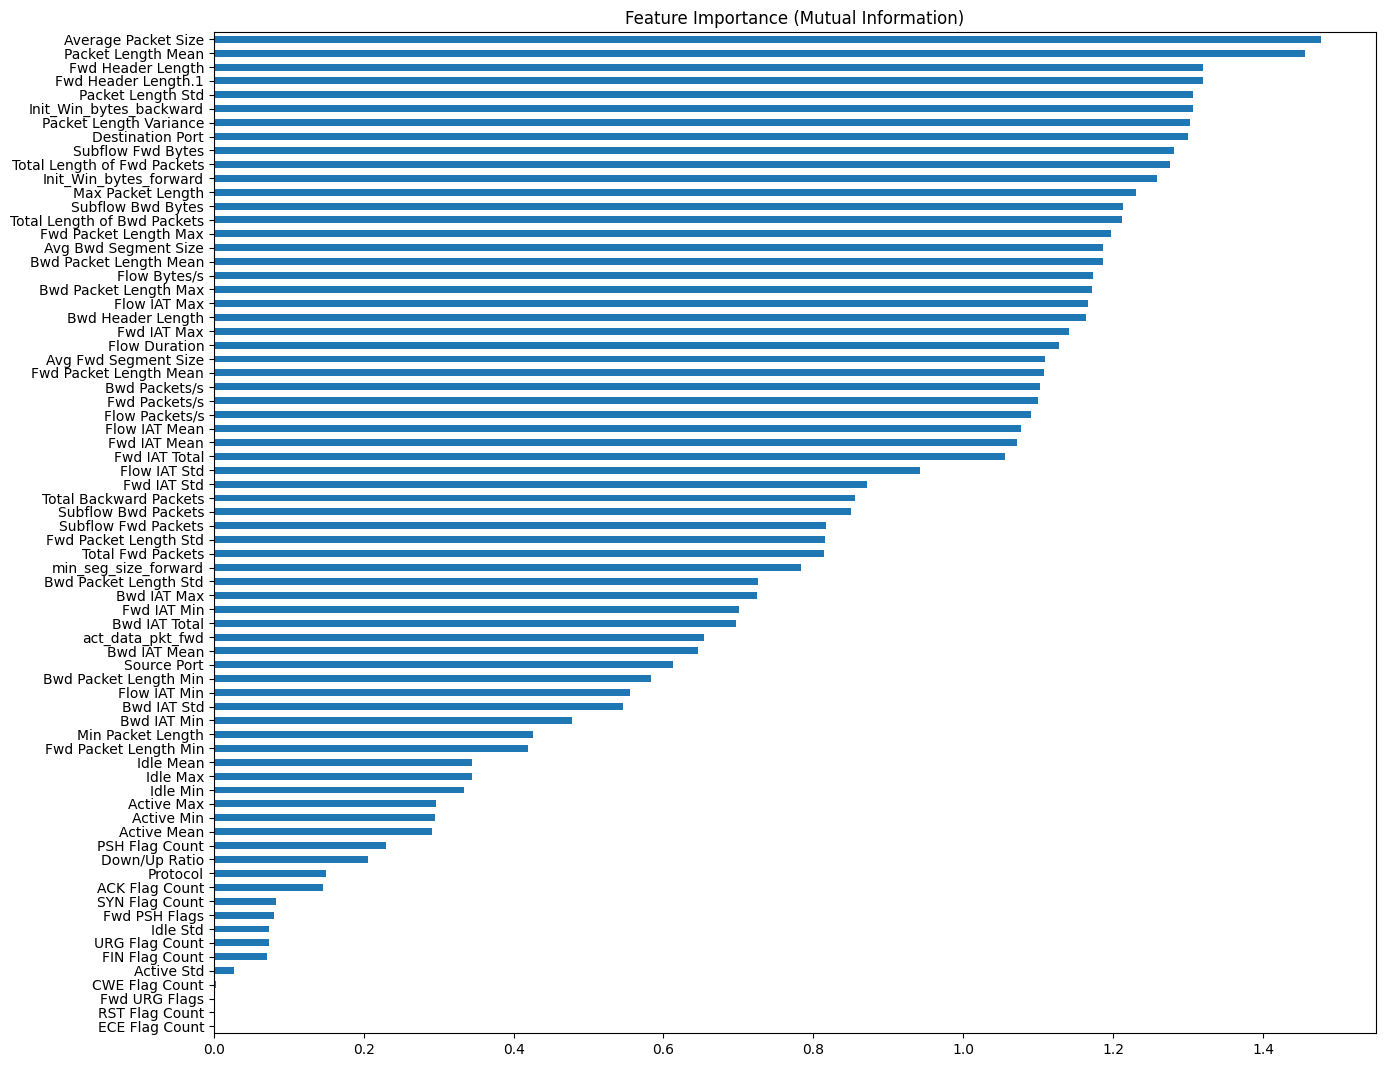

In [32]:
import matplotlib.pyplot as plt

scores_sorted.plot(kind='barh', figsize=(15,13))
plt.gca().invert_yaxis()
plt.title("Feature Importance (Mutual Information)")
plt.show()

In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train_sel, y_train)

In [34]:
y_test.value_counts()

Label
BENIGN          1400
PORTSCAN        1400
DOS             1400
DDOS            1400
BRUTE_FORCE     1400
WEB_ATTACK       436
BOT              394
INFILTRATION       7
EXPLOIT            2
Name: count, dtype: int64

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    max_features='sqrt',
    random_state=0,
    n_jobs=-1
)
print('Random Forest Model')

cv_rf = cross_val_score(
    rf,
    X_train_bal,
    y_train_bal,
    cv=3,
    n_jobs=1
)

print(f'\nCross-validation scores: {cv_rf}')
print(f'Mean cross-validation score: {cv_rf.mean():.4f}')

Random Forest Model

Cross-validation scores: [0.99833333 0.99761905 0.99833333]
Mean cross-validation score: 0.9981


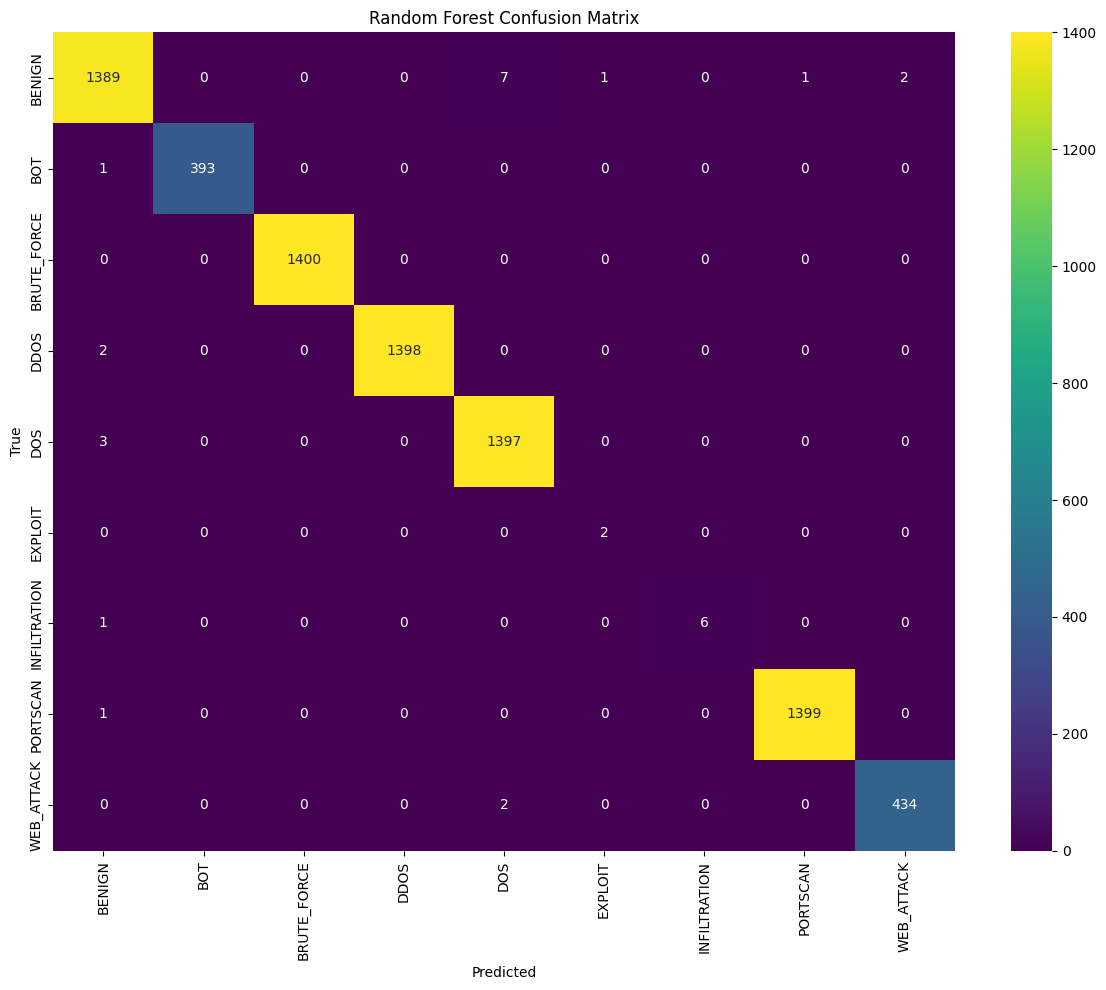

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# entrenar modelo final
rf.fit(X_train_bal, y_train_bal)

# predicción
y_pred_rf = rf.predict(X_test_sel)

# matriz de confusión
labels = rf.classes_   
cm = confusion_matrix(y_test, y_pred_rf, labels=labels)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    cmap="viridis",   
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

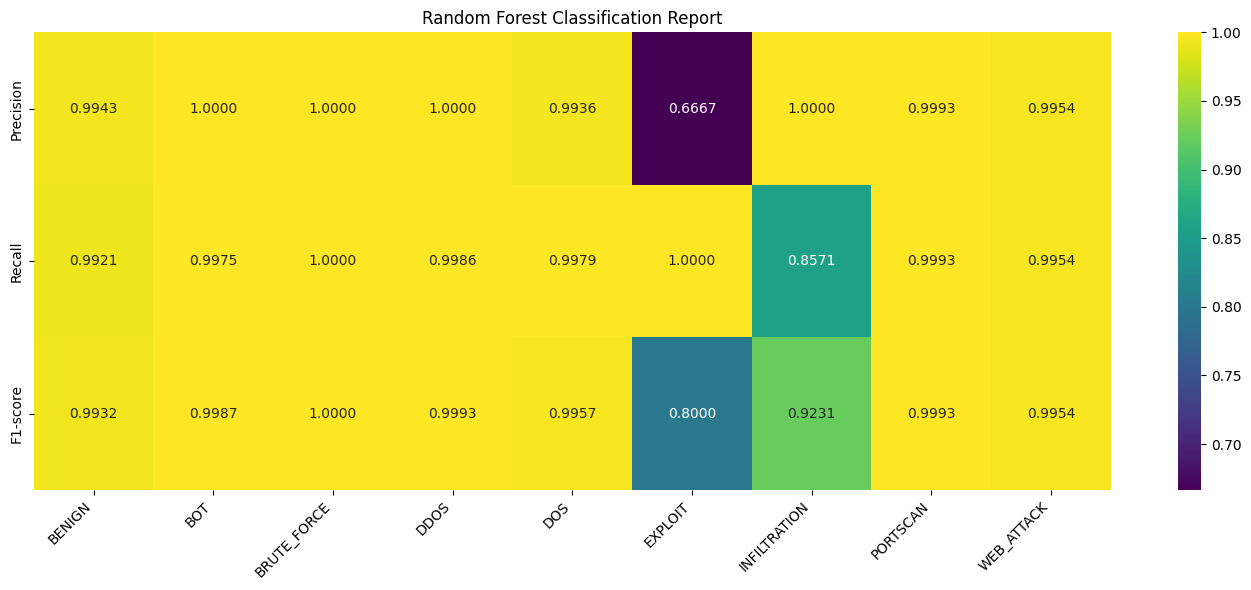

In [37]:
from sklearn.metrics import classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones
y_pred_rf = rf.predict(X_test_sel)

# Classification report
target_names = rf.classes_

metrics = classification_report(
    y_true=y_test,
    y_pred=y_pred_rf,
    target_names=target_names,
    output_dict=True
)

precision = [metrics[c]['precision'] for c in target_names]
recall = [metrics[c]['recall'] for c in target_names]
f1_score = [metrics[c]['f1-score'] for c in target_names]

data = np.array([
    precision,
    recall,
    f1_score
])

rows = ['Precision', 'Recall', 'F1-score']

plt.figure(figsize=(14, 6))

sns.heatmap(
    data,
    cmap='viridis',      # prueba también Blues, coolwarm, magma...
    annot=True,
    fmt='.4f',
    xticklabels=target_names,
    yticklabels=rows
)

plt.title('Random Forest Classification Report')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [38]:
dt = DecisionTreeClassifier(
    max_depth=15,
    random_state=0
)

print('Decision Tree Model')

cv_dt = cross_val_score(dt, X_train_bal, y_train_bal, cv=3)

print(f'\nCross-validation scores: {cv_dt}')
print(f'Mean cross-validation score: {cv_dt.mean():.4f}')


Decision Tree Model

Cross-validation scores: [0.99744048 0.9964881  0.99755952]
Mean cross-validation score: 0.9972


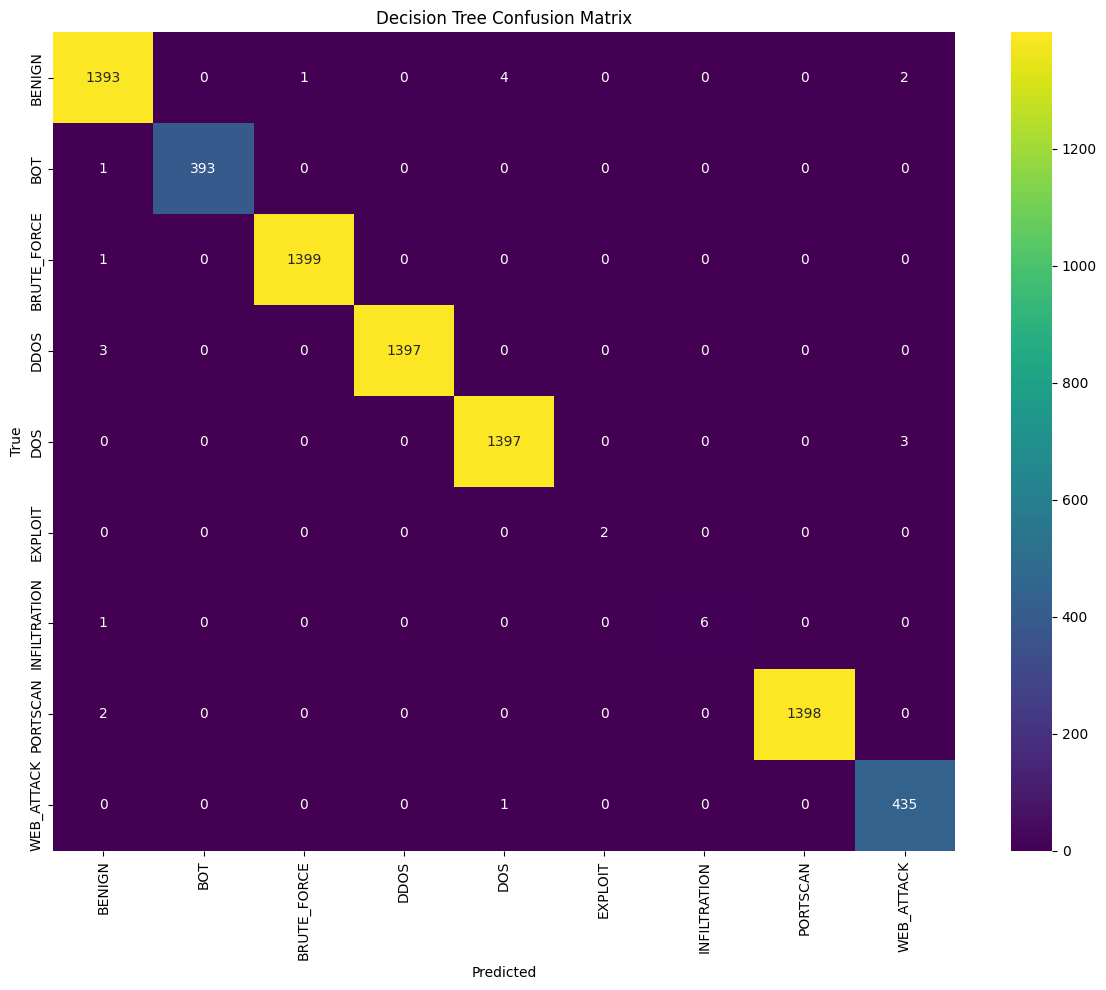

In [39]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# entrenar modelo final
dt.fit(X_train_bal, y_train_bal)

# predicción
y_pred_dt = dt.predict(X_test_sel)

# matriz de confusión
labels = dt.classes_   
cm = confusion_matrix(y_test, y_pred_dt, labels=labels)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    cmap="viridis",   
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

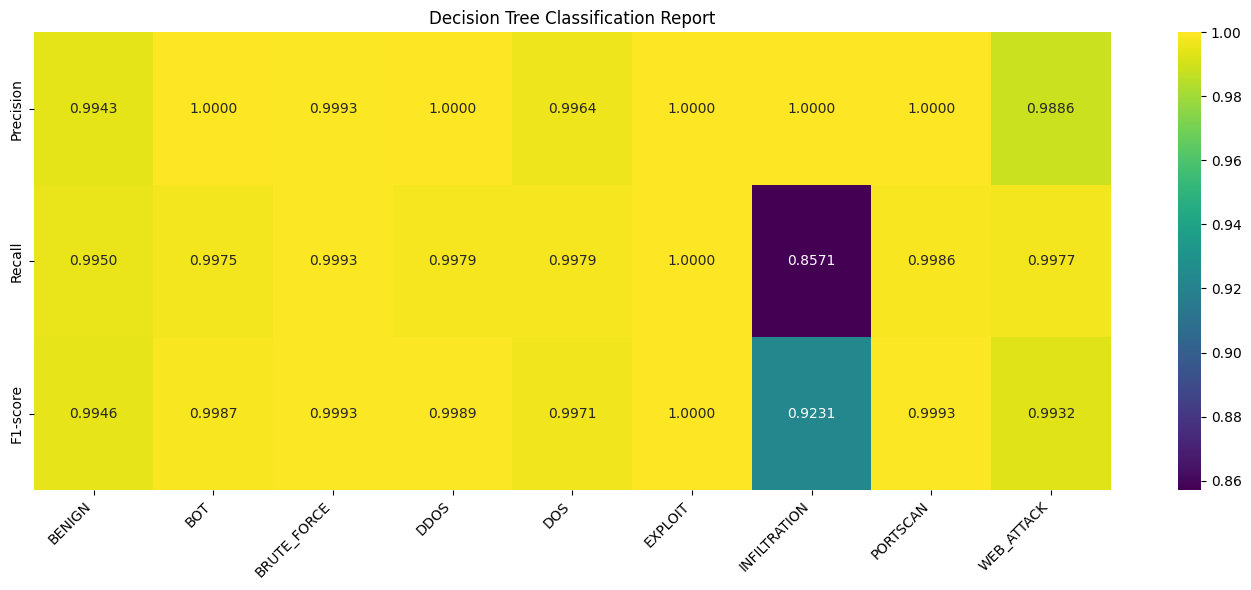

In [40]:
from sklearn.metrics import classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones
y_pred_dt = dt.predict(X_test_sel)

# Classification report
target_names = dt.classes_

metrics = classification_report(
    y_true=y_test,
    y_pred=y_pred_dt,
    target_names=target_names,
    output_dict=True
)

precision = [metrics[c]['precision'] for c in target_names]
recall = [metrics[c]['recall'] for c in target_names]
f1_score = [metrics[c]['f1-score'] for c in target_names]

data = np.array([
    precision,
    recall,
    f1_score
])

rows = ['Precision', 'Recall', 'F1-score']

plt.figure(figsize=(14, 6))

sns.heatmap(
    data,
    cmap='viridis',      # prueba también Blues, coolwarm, magma...
    annot=True,
    fmt='.4f',
    xticklabels=target_names,
    yticklabels=rows
)

plt.title('Decision Tree Classification Report')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test_sel)

k_values = [3, 5, 7, 9, 11, 15]

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    cv_knn_k = cross_val_score(
        knn_k, X_train_scaled, y_train_bal, cv=3, n_jobs=1
    )
    print(f'KNN k={k}: CV scores={cv_knn_k}, Mean={cv_knn_k.mean():.4f}')


KNN k=3: CV scores=[0.98910714 0.9889881  0.99035714], Mean=0.9895
KNN k=5: CV scores=[0.98702381 0.98684524 0.98910714], Mean=0.9877
KNN k=7: CV scores=[0.98583333 0.98577381 0.98779762], Mean=0.9865
KNN k=9: CV scores=[0.98410714 0.98428571 0.9860119 ], Mean=0.9848
KNN k=11: CV scores=[0.98244048 0.98339286 0.98482143], Mean=0.9836
KNN k=15: CV scores=[0.98017857 0.98053571 0.98184524], Mean=0.9809


In [42]:
# Modelo KNN final con el mejor k
knn = KNeighborsClassifier(n_neighbors=3)

print("KNN Model (k=3)")

# scaler ya definido en la celda anterior; reutilizar
cv_knn = cross_val_score(
    knn, X_train_scaled, y_train_bal, cv=3, n_jobs=-1
)

print(f"CV scores: {cv_knn}")
print(f"Mean accuracy: {cv_knn.mean():.4f}")


KNN Model (k=3)
CV scores: [0.98910714 0.9889881  0.99035714]
Mean accuracy: 0.9895


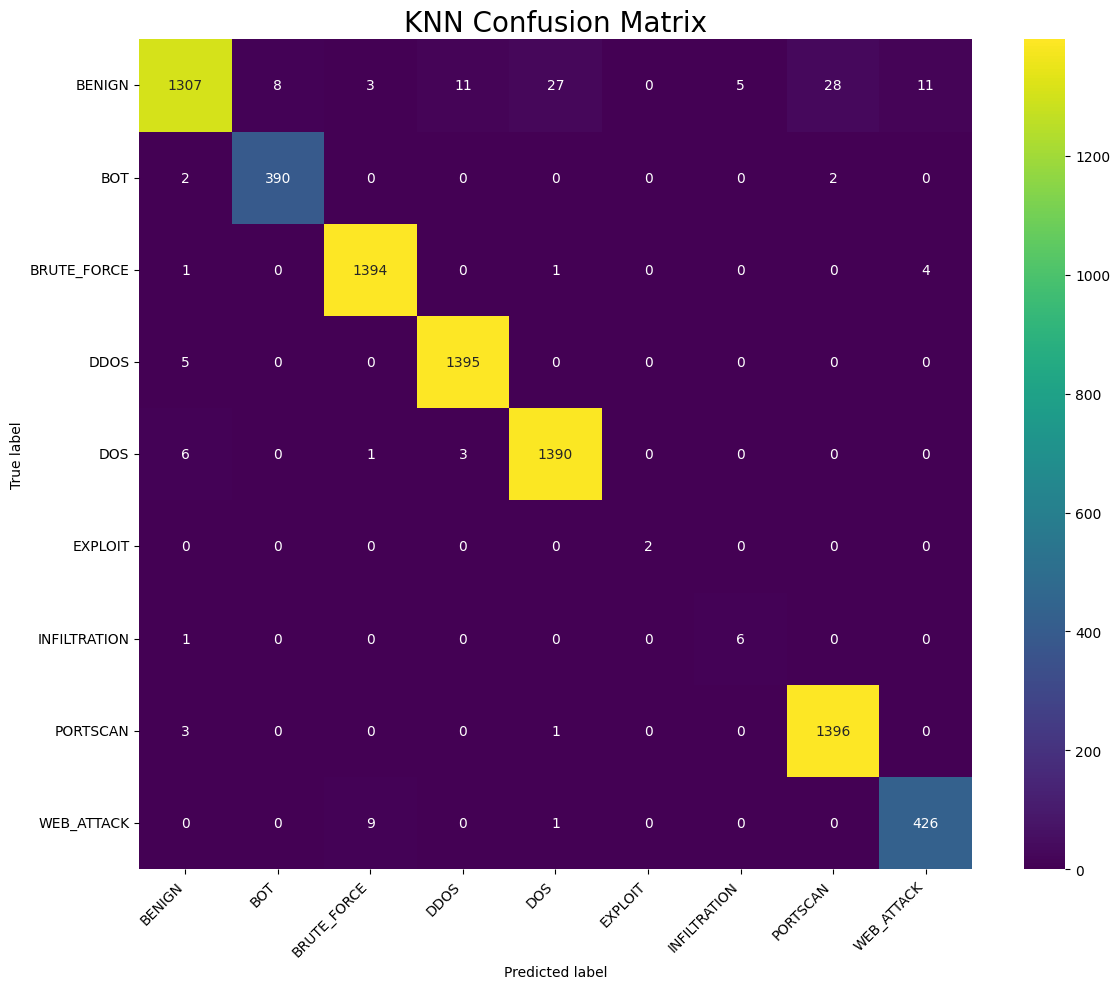

In [43]:
# Entrenar KNN y predecir usando datos escalados
knn.fit(X_train_scaled, y_train_bal)

y_pred_knn = knn.predict(X_test_scaled)

labels = knn.classes_
cm = confusion_matrix(y_test, y_pred_knn, labels=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, cmap="viridis", annot=True, fmt="d",
    xticklabels=labels, yticklabels=labels
)
plt.title("KNN Confusion Matrix", fontsize=20)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


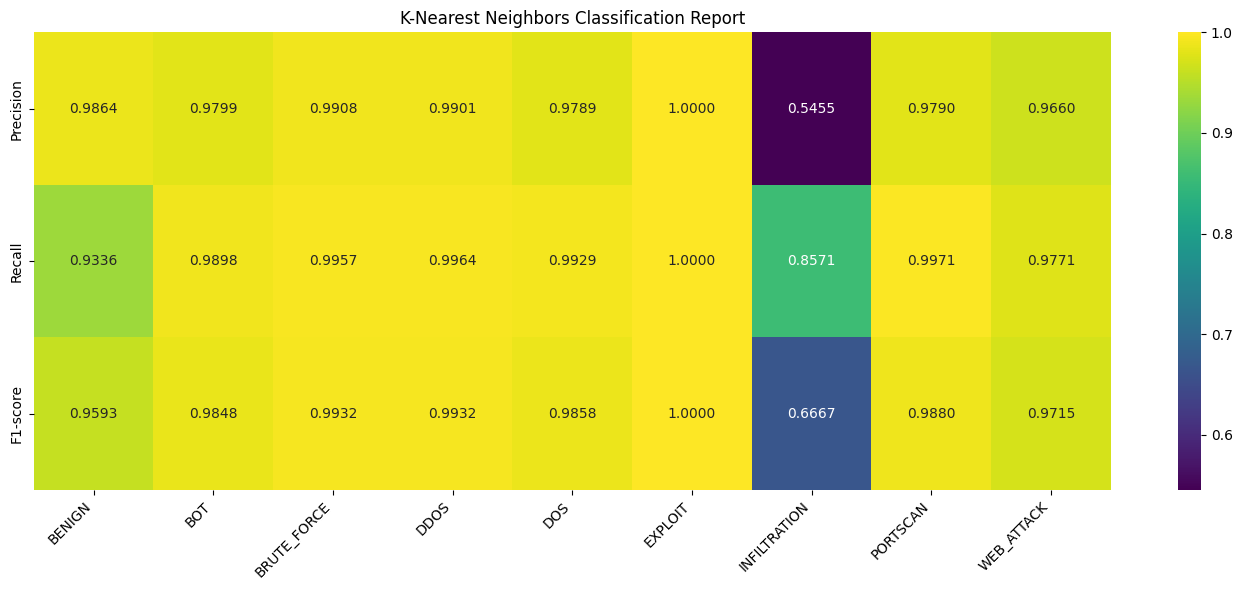

In [44]:
from sklearn.metrics import classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones
y_pred_knn = knn.predict(X_test_scaled)

# Classification report
target_names = knn.classes_

metrics = classification_report(
    y_true=y_test,
    y_pred=y_pred_knn,
    target_names=target_names,
    output_dict=True
)

precision = [metrics[c]['precision'] for c in target_names]
recall = [metrics[c]['recall'] for c in target_names]
f1_scores = [metrics[c]['f1-score'] for c in target_names]

data = np.array([
    precision,
    recall,
    f1_scores
])

rows = ['Precision', 'Recall', 'F1-score']

plt.figure(figsize=(14, 6))

sns.heatmap(
    data,
    cmap='viridis',  
    annot=True,
    fmt='.4f',
    xticklabels=target_names,
    yticklabels=rows
)

plt.title('K-Nearest Neighbors Classification Report')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [45]:
X_train.columns


Index(['Source Port', 'Destination Port', 'Protocol', 'Flow Duration',
       'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count',
       '

In [46]:
y.value_counts()

Label
BENIGN          7000
BRUTE_FORCE     7000
DDOS            7000
DOS             7000
PORTSCAN        7000
WEB_ATTACK      2180
BOT             1966
INFILTRATION      36
EXPLOIT           11
Name: count, dtype: int64